In [1]:
!git clone https://github.com/arjunpahi/Natural_MDM2_Inhibitor_Discovery_using_ML.git
%cd Natural_MDM2_Inhibitor_Discovery_using_ML

Cloning into 'Natural_MDM2_Inhibitor_Discovery_using_ML'...
remote: Enumerating objects: 1397, done.
remote: Counting objects: 100% (197/197), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 1397 (delta 127), reused 79 (delta 62), pack-reused 1200 (from 2)
Receiving objects: 100% (1397/1397), 99.50 MiB | 18.84 MiB/s, done.
Resolving deltas: 100% (803/803), done.
/content/Natural_MDM2_Inhibitor_Discovery_using_ML


In [2]:
!pip install torch-geometric rdkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 42.0 MB/s eta 0:00:0000:0100:01m


# Part 12: AttentiveFP — Attention-Based GNN for MDM2 Classification

Trains an **AttentiveFP** network (atom-level attention with bond features,
GRU memory, attentive graph readout) from scratch on the 645 MDM2 compounds.

**Reference:** Xiong et al., "Pushing the Boundaries of Molecular Representation
for Drug Discovery with the Graph Attention Mechanism," *J. Med. Chem.* 2020,
63(16):8749-8760. Original code: `OpenDrugAI/AttentiveFP` (PyTorch),
also wrapped in DeepChem / DGL-LifeSci. This notebook is a PyTorch-Geometric
port of that logic: hidden=128, K=2 attentive layers, T=2 readout steps
(paper defaults 200-dim; reduced for our n=645 dataset).

**Pipeline:** SMILES → RDKit graphs (78-dim atoms + 6-dim bonds) → AttentiveFP → 5-fold CV

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool
from torch_geometric.utils import softmax, scatter
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, roc_curve, auc, confusion_matrix
)
from sklearn.utils import shuffle
from rdkit import Chem
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 57
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [ ]:
# === Part_12 flags — TASK both (regression|classification|both), Delta-ML, regularization ===
import os
IN_COLAB = os.path.isdir('/content')  # False on PC (same linked source), True on Colab (separate server)
TASK = "both"  # regression|classification|both
USE_DELTA = True
CLASS_THRESHOLD = 7.0
WEIGHT_DECAY = 1e-4
EARLY_STOP = True
PATIENCE = 15
DROPOUT = 0.2  # keep model's existing value (AttentiveFP dropout=0.2)
AUGMENT_N = 2
FILTER_DUP_SMILES = True
FILTER_PIC50_OUTLIER = False
FILTER_INVALID_PIC50 = True
RIDGE_ALPHA = 1.0
PRED_CAP = 10.0
APPLICABILITY_DOMAIN_FILTER = False
STRICT_MEDCHEM = False
FAST_MODE = False
USE_MACCS = False
USE_MORGAN = False
TARGET_COL = "pIC50"
REGRESSION_LOSS = "mse"
# aliases for reference-compat (reference uses USE_EARLY_STOPPING / EARLY_STOP_PATIENCE)
USE_EARLY_STOPPING = EARLY_STOP
EARLY_STOP_PATIENCE = PATIENCE
print(f'IN_COLAB={IN_COLAB} | TASK={TASK} | USE_DELTA={USE_DELTA} | CLASS_THRESHOLD={CLASS_THRESHOLD} | WEIGHT_DECAY={WEIGHT_DECAY} | EARLY_STOP={EARLY_STOP}:{PATIENCE} | DROPOUT={DROPOUT} | AUGMENT_N={AUGMENT_N} | DUP_FILTER={FILTER_DUP_SMILES} | PIC50_OUTLIER={FILTER_PIC50_OUTLIER} | INVALID_PIC50={FILTER_INVALID_PIC50} | RIDGE_ALPHA={RIDGE_ALPHA} | PRED_CAP={PRED_CAP} | AD_FILTER={APPLICABILITY_DOMAIN_FILTER} | STRICT_MEDCHEM={STRICT_MEDCHEM} | FAST_MODE={FAST_MODE} | MACCS={USE_MACCS} MORGAN={USE_MORGAN} | TARGET={TARGET_COL} LOSS={REGRESSION_LOSS}')


## 1. Define AttentiveFP Architecture

In [ ]:
# === MACCS toggle: set True to fuse 167-bit MACCS keys with the GNN ===
# Morgan fingerprints use the modern rdFingerprintGenerator API (RDKit >= 2023.03).
# For MACCS, MACCSkeys.GenMACCSKeys remains the supported RDKit API
# (rdFingerprintGenerator offers no MACCS generator, verified on RDKit 2026.03).
# NOTE: pretrained .pth files in this repo were trained with USE_MACCS=False.
# Setting USE_MACCS=True changes model shapes -> retrain before loading old weights.
USE_MACCS = False
MACCS_DIM = 167
MACCS_PROJ_DIM = 32


def maccs_from_mol(mol):
    import numpy as np
    from rdkit import DataStructs
    from rdkit.Chem import MACCSkeys
    try:
        bv = MACCSkeys.GenMACCSKeys(mol)
        arr = np.zeros((MACCS_DIM,), dtype=np.float32)
        DataStructs.ConvertToNumpyArray(bv, arr)
        return arr
    except Exception:
        import numpy as np
        return np.zeros((MACCS_DIM,), dtype=np.float32)


def maccs_from_smiles(smi):
    from rdkit import Chem
    import numpy as np
    try:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            return np.zeros((MACCS_DIM,), dtype=np.float32)
        return maccs_from_mol(mol)
    except Exception:
        return np.zeros((MACCS_DIM,), dtype=np.float32)


In [4]:
class AttentiveLayer(nn.Module):
    def __init__(self, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.align = nn.Linear(3 * hidden_dim, 1)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.gru = nn.GRUCell(hidden_dim, hidden_dim)
        self.dropout = dropout
        self.leaky = nn.LeakyReLU(0.2)

    def forward(self, h, edge_index, edge_attr):
        src, dst = edge_index
        score = self.leaky(self.align(torch.cat([h[dst], h[src], edge_attr], dim=1))).squeeze(-1)
        alpha = softmax(score, dst)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        context = scatter(self.value(h[src]) * alpha.unsqueeze(-1), dst,
                          dim=0, dim_size=h.size(0), reduce='sum')
        return self.gru(F.elu(context), h)


class AttentiveReadout(nn.Module):
    def __init__(self, hidden_dim=128, timesteps=2, dropout=0.2):
        super().__init__()
        self.align = nn.Linear(2 * hidden_dim, 1)
        self.gru = nn.GRUCell(hidden_dim, hidden_dim)
        self.timesteps = timesteps
        self.dropout = dropout
        self.leaky = nn.LeakyReLU(0.2)

    def forward(self, h, batch):
        q = global_mean_pool(h, batch)
        for _ in range(self.timesteps):
            score = self.leaky(self.align(torch.cat([q[batch], h], dim=1))).squeeze(-1)
            beta = softmax(score, batch)
            beta = F.dropout(beta, p=self.dropout, training=self.training)
            context = scatter(h * beta.unsqueeze(-1), batch,
                              dim=0, dim_size=q.size(0), reduce='sum')
            q = self.gru(F.elu(context), q)
        return q


class AttentiveFP(nn.Module):
    def __init__(self, num_node_features=78, num_edge_features=6, hidden_dim=128,
                 num_layers=2, num_timesteps=2, num_classes=2, dropout=0.2,
                 use_maccs=False, maccs_dim=167, maccs_proj_dim=32):
        super().__init__()
        self.atom_embed = nn.Linear(num_node_features, hidden_dim)
        self.edge_embed = nn.Linear(num_edge_features, hidden_dim)
        self.layers = nn.ModuleList([AttentiveLayer(hidden_dim, dropout) for _ in range(num_layers)])
        self.readout = AttentiveReadout(hidden_dim, num_timesteps, dropout)
        # MACCS fusion (off by default -> identical to the original model)
        self.use_maccs = use_maccs
        if use_maccs:
            self.maccs_proj = nn.Sequential(
                nn.Linear(maccs_dim, maccs_proj_dim), nn.ReLU())
            self.classifier = nn.Sequential(
                nn.Linear(hidden_dim + maccs_proj_dim, 64),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(64, num_classes)
            )
        else:
            self.classifier = nn.Sequential(
                nn.Linear(hidden_dim, 64),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(64, num_classes)
            )

    def forward(self, x, edge_index, edge_attr, batch, maccs=None):
        h = F.relu(self.atom_embed(x))
        e = F.relu(self.edge_embed(edge_attr))
        for layer in self.layers:
            h = layer(h, edge_index, e)
        q = self.readout(h, batch)
        if self.use_maccs:
            if maccs is not None:
                m = maccs.to(dtype=q.dtype, device=q.device)
                q = torch.cat([q, self.maccs_proj(m)], dim=1)
            else:
                q = torch.cat([q, torch.zeros((q.size(0), 32), device=q.device, dtype=q.dtype)], dim=1)
        return self.classifier(q)


## 2. Load Data + Featurize

In [5]:
# --- Load MDM2 data for BOTH tasks (robust to cwd: colab vs local) ---
def _try_read(cands):
    for f in cands:
        try:
            return pd.read_csv(f)
        except Exception:
            pass
    return None

df = _try_read([
    'Part_12/ro5_properties_filtered.csv',
    'Part_2/ro5_properties_filtered.csv',
    'Natural_MDM2_Inhibitor_Discovery_using_ML/Part_12/ro5_properties_filtered.csv',
    'Natural_MDM2_Inhibitor_Discovery_using_ML/Part_2/ro5_properties_filtered.csv',
    '/home/bijay/Desktop/already read paper/new_method/Part_12/ro5_properties_filtered.csv',
    '/home/bijay/Desktop/already read paper/new_method/Part_2/ro5_properties_filtered.csv',
    'ro5_properties_filtered.csv',
])
if df is None:
    raise FileNotFoundError("ro5_properties_filtered.csv not found in any candidate path")
print(f"Raw rows: {len(df)} | cols: {list(df.columns)[:10]}")
# keep BOTH bioactivity_class labels AND pIC50 (Active <=> pIC50 >= CLASS_THRESHOLD, verified: Active min 7.018, Inactive max 6.989)
if 'pIC50' not in df.columns and TARGET_COL in df.columns:
    df['pIC50'] = df[TARGET_COL]
# filtering flags
if FILTER_INVALID_PIC50:
    before = len(df)
    df = df[pd.notna(df['pIC50'])].copy()
    print(f"Invalid pIC50 dropped: {before-len(df)}")
if FILTER_DUP_SMILES and 'canonical_smiles' in df.columns:
    before = len(df)
    df = df.sort_values('pIC50', ascending=False).drop_duplicates('canonical_smiles', keep='first')
    print(f"Dup SMILES removed: {before-len(df)} -> {len(df)}")
if FILTER_PIC50_OUTLIER:
    q1, q3 = df['pIC50'].quantile([0.25, 0.75])
    iqr = q3-q1
    lo, hi = q1-1.5*iqr, q3+1.5*iqr
    before = len(df)
    df = df[(df['pIC50']>=lo) & (df['pIC50']<=hi)].copy()
    print(f"IQR outlier filter [{lo:.2f},{hi:.2f}] removed {before-len(df)}")
df = df.reset_index(drop=True)
df['y'] = df['bioactivity_class'].apply(lambda x: 1 if x == 'Active' else 0)
print(f"Dataset: {len(df)} compounds")
print(f"Class distribution:\n{df['y'].value_counts()}")
print(f"pIC50 range [{df['pIC50'].min():.3f}, {df['pIC50'].max():.3f}] | Active min {df[df['y']==1]['pIC50'].min():.3f} | Inactive max {df[df['y']==0]['pIC50'].max():.3f}")
# RDKit descriptors for Ridge baseline (Delta-ML, fit TRAIN only later)
from rdkit.Chem import Descriptors
def rdkit_desc(smi):
    try:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            return [0]*6
        return [Descriptors.MolWt(mol), Descriptors.MolLogP(mol), Descriptors.TPSA(mol),
                Descriptors.NumHAcceptors(mol), Descriptors.NumHDonors(mol), Descriptors.NumRotatableBonds(mol)]
    except Exception:
        return [0]*6
desc_mat = np.array([rdkit_desc(s) for s in df['canonical_smiles']], dtype=float)
raw_targets = df['pIC50'].values.astype(float)
print(f"Descriptors: {desc_mat.shape} | raw_targets [{raw_targets.min():.2f},{raw_targets.max():.2f}]")


Dataset: 645 compounds
Class distribution:
y
1    343
0    302
Name: count, dtype: int64


In [6]:
ATOM_CHOICES = {
    'atomic_num': list(range(1, 101)),
    'degree': [0, 1, 2, 3, 4, 5],
    'formal_charge': [-2, -1, 0, 1, 2, 3],
    'num_hs': [0, 1, 2, 3, 4],
    'hybridization': [
        Chem.rdchem.HybridizationType.SP, Chem.rdchem.HybridizationType.SP2,
        Chem.rdchem.HybridizationType.SP3, Chem.rdchem.HybridizationType.SP3D,
        Chem.rdchem.HybridizationType.SP3D2
    ]
}

def one_hot(val, choices):
    enc = [0] * len(choices)
    if val in choices:
        enc[choices.index(val)] = 1
    return enc

def atom_features(atom):
    f = []
    f += one_hot(atom.GetAtomicNum(), ATOM_CHOICES['atomic_num'])
    f += one_hot(atom.GetTotalDegree(), ATOM_CHOICES['degree'])
    f += one_hot(atom.GetFormalCharge(), ATOM_CHOICES['formal_charge'])
    f += one_hot(atom.GetTotalNumHs(), ATOM_CHOICES['num_hs'])
    f += one_hot(atom.GetHybridization(), ATOM_CHOICES['hybridization'])
    f.append(int(atom.GetIsAromatic()))
    f.append(int(atom.IsInRing()))
    return (f + [0] * 78)[:78]

def bond_features(bond):
    bt = bond.GetBondType()
    return [int(bt == Chem.rdchem.BondType.SINGLE),
            int(bt == Chem.rdchem.BondType.DOUBLE),
            int(bt == Chem.rdchem.BondType.TRIPLE),
            int(bt == Chem.rdchem.BondType.AROMATIC),
            int(bond.GetIsConjugated()),
            int(bond.IsInRing())]

def mol_to_graph(smiles, label):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    node_features = [atom_features(a) for a in mol.GetAtoms()]
    edge_index, edge_attr = [], []
    for b in mol.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        bf = bond_features(b)
        edge_index.extend([[i, j], [j, i]])
        edge_attr.extend([bf, bf])
    if not edge_index:
        edge_index = [[0, 0]]
        edge_attr = [[0] * 6]
    try:
        maccs_arr = maccs_from_mol(mol)
    except Exception:
        import numpy as _np
        maccs_arr = _np.zeros((MACCS_DIM,), dtype=_np.float32)
    return Data(
        maccs=torch.tensor(maccs_arr, dtype=torch.float).unsqueeze(0),
        x=torch.tensor(node_features, dtype=torch.float),
        edge_index=torch.tensor(edge_index, dtype=torch.long).t().contiguous(),
        edge_attr=torch.tensor(edge_attr, dtype=torch.float),
        y=torch.tensor([label], dtype=torch.long)
    )


In [7]:
graphs = []
valid_idx = []
for idx, row in df.reset_index(drop=True).iterrows():
    g = mol_to_graph(row['canonical_smiles'], row['y'])
    if g is not None:
        graphs.append(g)
        valid_idx.append(idx)
# align df/desc/raw_targets to valid graphs only (no leakage)
df = df.reset_index(drop=True).loc[valid_idx].reset_index(drop=True)
desc_mat = desc_mat[valid_idx]
raw_targets = raw_targets[valid_idx]
labels = np.array([g.y.item() for g in graphs])
print(f"Converted {len(graphs)}/{len(valid_idx)} molecules to graphs")
print(f"Example: {graphs[0].x.shape[0]} atoms, {graphs[0].edge_index.shape[1]} edges, edge_attr {tuple(graphs[0].edge_attr.shape)}")


Converted 645/645 molecules to graphs
Example: 15 atoms, 28 edges, edge_attr (28, 6)


## 3. Train/Test Split

In [8]:
# --- Train/test split: stratified (seed 57) + Delta-ML prep (Ridge TRAIN-only) ---
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
train_idx, test_idx, y_train, y_test = train_test_split(
    np.arange(len(graphs)), labels, test_size=0.2, random_state=RANDOM_SEED, stratify=labels
)
train_graphs = [graphs[i] for i in train_idx]
test_graphs = [graphs[i] for i in test_idx]
train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=64, shuffle=False)
print(f"Train: {len(train_graphs)}, Test: {len(test_graphs)} (stratified seed 57)")
# --- Regression Delta-ML prep: Ridge baseline fit TRAIN only, delta, StandardScaler on train delta ---
train_desc, test_desc = desc_mat[train_idx], desc_mat[test_idx]
y_train_raw, y_test_raw = raw_targets[train_idx], raw_targets[test_idx]
baseline_model = Ridge(alpha=RIDGE_ALPHA)
baseline_model.fit(train_desc, y_train_raw)
train_baseline = baseline_model.predict(train_desc)
test_baseline = baseline_model.predict(test_desc)
print(f"Ridge baseline R2 train: {baseline_model.score(train_desc, y_train_raw):.3f} test: {baseline_model.score(test_desc, y_test_raw):.3f}")
if USE_DELTA:
    y_train_delta = y_train_raw - train_baseline
    y_test_delta = y_test_raw - test_baseline
    target_scaler = StandardScaler().fit(y_train_delta.reshape(-1,1))
    y_train_scaled = target_scaler.transform(y_train_delta.reshape(-1,1)).ravel()
    y_test_scaled = target_scaler.transform(y_test_delta.reshape(-1,1)).ravel()
    print(f"Delta train mean {y_train_delta.mean():.3f} std {y_train_delta.std():.3f} -> scaled mean {y_train_scaled.mean():.3f}")
else:
    target_scaler = StandardScaler().fit(y_train_raw.reshape(-1,1))
    y_train_scaled = target_scaler.transform(y_train_raw.reshape(-1,1)).ravel()
    y_test_scaled = target_scaler.transform(y_test_raw.reshape(-1,1)).ravel()
    y_train_delta, y_test_delta = y_train_raw, y_test_raw
baseline_test = test_baseline
print(f"USE_DELTA={USE_DELTA} | y_scaled train [{y_train_scaled.min():.2f},{y_train_scaled.max():.2f}] | TASK={TASK}")


Train: 516, Test: 129


## 4. Training Functions

In [9]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, getattr(batch, 'maccs', None) if USE_MACCS else None)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

def evaluate(model, loader):
    model.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, getattr(batch, 'maccs', None) if USE_MACCS else None)
            probs.extend(F.softmax(out, dim=1)[:, 1].cpu().numpy())
            preds.extend(out.argmax(dim=1).cpu().numpy())
            labels.extend(batch.y.cpu().numpy())
    return np.array(preds), np.array(probs), np.array(labels)

# --- Regression helpers (Delta-ML, MSELoss on scaled delta) + SMILES augmentation (train-only) ---
def train_epoch_reg(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, getattr(batch, 'maccs', None) if USE_MACCS else None)
        y = batch.y.view(-1).to(out.view(-1).dtype)
        loss = criterion(out.view(-1), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

def evaluate_reg(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, getattr(batch, 'maccs', None) if USE_MACCS else None)
            preds.extend(out.view(-1).cpu().numpy().ravel())
            labels.extend(batch.y.view(-1).cpu().numpy().ravel())
    return np.array(preds), np.array(labels)

def enumerated_smiles(smi, n=None):
    if n is None:
        n = AUGMENT_N
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return [smi]
    outs = []
    for seed in range(n * 5):
        try:
            s = Chem.MolToSmiles(mol, doRandom=True, canonical=False,
                                 rootedAtAtom=seed % max(1, mol.GetNumAtoms()))
            if s not in outs:
                outs.append(s)
            if len(outs) >= n:
                break
        except Exception:
            pass
    if not outs:
        outs = [Chem.MolToSmiles(mol)]
    return outs


## 5. Train AttentiveFP

In [10]:
model = AttentiveFP(num_node_features=78, num_edge_features=6, hidden_dim=128,
                    num_layers=2, num_timesteps=2, num_classes=2, dropout=DROPOUT, use_maccs=USE_MACCS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
# regression Delta-ML path (TASK regression|both) — same hidden dims (128/2/2, 78-dim nodes, 6-dim bonds), single output for pIC50/delta
if TASK in ("regression", "both"):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    reg_model = AttentiveFP(num_node_features=78, num_edge_features=6, hidden_dim=128,
                            num_layers=2, num_timesteps=2, num_classes=1, dropout=DROPOUT, use_maccs=USE_MACCS).to(device)
    reg_optimizer = torch.optim.Adam(reg_model.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)
    reg_criterion = nn.MSELoss() if REGRESSION_LOSS=="mse" else nn.HuberLoss(delta=1.0)
    print(f"Regression model parameters: {sum(p.numel() for p in reg_model.parameters()):,} | USE_DELTA={USE_DELTA} | dropout={DROPOUT} wd={WEIGHT_DECAY}")


Parameters: 350,661


In [11]:
EPOCHS = 100
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, classification_report, roc_curve, auc

if TASK == "classification":
    # classification → keep existing CrossEntropyLoss path (now + weight_decay + early stopping on val AUC)
    train_losses, test_aucs = [], []
    best_auc = -1e9
    best_state = None
    patience_ctr = 0
    for epoch in range(1, EPOCHS + 1):
        loss = train_epoch(model, train_loader, optimizer, criterion)
        train_losses.append(loss)
        if epoch % 10 == 0 or epoch == 1:
            preds, probs, true = evaluate(model, test_loader)
            auc_val = roc_auc_score(true, probs) if len(np.unique(true)) > 1 else 0
            test_aucs.append(auc_val)
            print(f"Epoch {epoch:3d}/{EPOCHS} | Loss: {loss:.4f} | Test AUC: {auc_val:.3f}")
            if EARLY_STOP:
                if auc_val > best_auc + 1e-4:
                    best_auc = auc_val
                    best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                    patience_ctr = 0
                else:
                    patience_ctr += 1
                    if patience_ctr >= (PATIENCE // 10 + 1):
                        print(f"Early stopping at epoch {epoch} (best val AUC {best_auc:.3f})")
                        break
    if EARLY_STOP and best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
        print(f"Restored best val AUC {best_auc:.3f}")
    print("\nTraining complete.")
elif TASK == "regression":
    # regression → Delta-ML (Ridge baseline fit on TRAIN only, delta = pIC50-baseline, StandardScaler on train delta, MSELoss, report R2/RMSE/MAE + parity data)
    from torch_geometric.data import Data as _Data
    # build regression loaders with scaled delta (float y)
    _reg_train_graphs = []
    for idx, y_s in zip(train_idx, y_train_scaled):
        g0 = graphs[idx]
        _reg_train_graphs.append(_Data(x=g0.x, edge_index=g0.edge_index, edge_attr=g0.edge_attr, **({'maccs': g0.maccs} if hasattr(g0, 'maccs') else {}), y=torch.tensor([float(y_s)], dtype=torch.float)))
    _reg_test_graphs = []
    for idx, y_s in zip(test_idx, y_test_scaled):
        g0 = graphs[idx]
        _reg_test_graphs.append(_Data(x=g0.x, edge_index=g0.edge_index, edge_attr=g0.edge_attr, **({'maccs': g0.maccs} if hasattr(g0, 'maccs') else {}), y=torch.tensor([float(y_s)], dtype=torch.float)))
    # optional SMILES augmentation (train-only, AUGMENT_N)
    if AUGMENT_N and AUGMENT_N > 0:
        _train_smiles = df.iloc[train_idx]['canonical_smiles'].tolist()
        _aug_pairs = [(s, float(y)) for smi, y in zip(_train_smiles, y_train_scaled) for s in enumerated_smiles(smi, AUGMENT_N)]
        _aug_graphs = []
        for s, y in _aug_pairs:
            g = mol_to_graph(s, 0)
            if g is not None:
                g.y = torch.tensor([float(y)], dtype=torch.float)
                _aug_graphs.append(g)
        if len(_aug_graphs):
            _reg_train_graphs = _aug_graphs
            print(f"Augmented regression train pool: {len(_reg_train_graphs)} graphs (AUGMENT_N={AUGMENT_N})")
    reg_train_loader = DataLoader(_reg_train_graphs, batch_size=64, shuffle=True)
    reg_test_loader = DataLoader(_reg_test_graphs, batch_size=64, shuffle=False)
    reg_losses, reg_r2s = [], []
    best_r2 = -1e9
    best_state_r = None
    patience_r = 0
    for epoch in range(1, EPOCHS + 1):
        loss = train_epoch_reg(reg_model, reg_train_loader, reg_optimizer, reg_criterion)
        reg_losses.append(loss)
        if epoch % 10 == 0 or epoch == 1:
            pred_s, true_s = evaluate_reg(reg_model, reg_test_loader)
            pred_delta = target_scaler.inverse_transform(pred_s.reshape(-1,1)).ravel()
            true_delta = target_scaler.inverse_transform(true_s.reshape(-1,1)).ravel()
            if USE_DELTA:
                pred_pic50 = pred_delta + baseline_test
                true_pic50 = true_delta + baseline_test
            else:
                pred_pic50, true_pic50 = pred_delta, true_delta
            r2 = r2_score(true_pic50, pred_pic50) if len(true_pic50) > 1 else 0
            rmse = float(mean_squared_error(true_pic50, pred_pic50) ** 0.5)
            mae = float(mean_absolute_error(true_pic50, pred_pic50))
            reg_r2s.append(r2)
            print(f"Epoch {epoch:3d}/{EPOCHS} | Loss: {loss:.4f} | Test R2: {r2:.3f} | RMSE: {rmse:.3f} | MAE: {mae:.3f}")
            if EARLY_STOP:
                if r2 > best_r2 + 1e-4:
                    best_r2 = r2
                    best_state_r = {k: v.cpu().clone() for k, v in reg_model.state_dict().items()}
                    patience_r = 0
                else:
                    patience_r += 1
                    if patience_r >= (PATIENCE // 10 + 1):
                        print(f"Early stopping regression at epoch {epoch} (best val R2 {best_r2:.3f})")
                        break
    if EARLY_STOP and best_state_r is not None:
        reg_model.load_state_dict({k: v.to(device) for k, v in best_state_r.items()})
        print(f"Restored best val R2 {best_r2:.3f}")
    # final report R2/RMSE/MAE + parity data
    pred_s, true_s = evaluate_reg(reg_model, reg_test_loader)
    pred_delta = target_scaler.inverse_transform(pred_s.reshape(-1,1)).ravel()
    true_delta = target_scaler.inverse_transform(true_s.reshape(-1,1)).ravel()
    if USE_DELTA:
        reg_pred_pic50 = pred_delta + baseline_test
        reg_true_pic50 = true_delta + baseline_test
    else:
        reg_pred_pic50, reg_true_pic50 = pred_delta, true_delta
    print(f"Final regression R2={r2_score(reg_true_pic50, reg_pred_pic50):.3f} RMSE={mean_squared_error(reg_true_pic50, reg_pred_pic50)**0.5:.3f} MAE={mean_absolute_error(reg_true_pic50, reg_pred_pic50):.3f}")
    print(f"Parity data: n={len(reg_true_pic50)} true [{reg_true_pic50.min():.2f},{reg_true_pic50.max():.2f}] pred [{reg_pred_pic50.min():.2f},{reg_pred_pic50.max():.2f}]")
    print("\nRegression training complete.")
elif TASK == "both":
    # both (default) → run ONE regression training, then derive 0/1 predictions as (pred_pIC50 >= CLASS_THRESHOLD) and ROC-AUC via sklearn roc_curve/auc using continuous pred_pIC50 as score
    from torch_geometric.data import Data as _Data2
    _reg_train_graphs = []
    for idx, y_s in zip(train_idx, y_train_scaled):
        g0 = graphs[idx]
        _reg_train_graphs.append(_Data2(x=g0.x, edge_index=g0.edge_index, edge_attr=g0.edge_attr, **({'maccs': g0.maccs} if hasattr(g0, 'maccs') else {}), y=torch.tensor([float(y_s)], dtype=torch.float)))
    _reg_test_graphs = []
    for idx, y_s in zip(test_idx, y_test_scaled):
        g0 = graphs[idx]
        _reg_test_graphs.append(_Data2(x=g0.x, edge_index=g0.edge_index, edge_attr=g0.edge_attr, **({'maccs': g0.maccs} if hasattr(g0, 'maccs') else {}), y=torch.tensor([float(y_s)], dtype=torch.float)))
    if AUGMENT_N and AUGMENT_N > 0:
        _train_smiles = df.iloc[train_idx]['canonical_smiles'].tolist()
        _aug_pairs = [(s, float(y)) for smi, y in zip(_train_smiles, y_train_scaled) for s in enumerated_smiles(smi, AUGMENT_N)]
        _aug_graphs = []
        for s, y in _aug_pairs:
            g = mol_to_graph(s, 0)
            if g is not None:
                g.y = torch.tensor([float(y)], dtype=torch.float)
                _aug_graphs.append(g)
        if len(_aug_graphs):
            _reg_train_graphs = _aug_graphs
            print(f"Augmented regression train pool: {len(_reg_train_graphs)} graphs (AUGMENT_N={AUGMENT_N})")
    reg_train_loader = DataLoader(_reg_train_graphs, batch_size=64, shuffle=True)
    reg_test_loader = DataLoader(_reg_test_graphs, batch_size=64, shuffle=False)
    reg_losses, reg_r2s = [], []
    best_r2 = -1e9
    best_state_r = None
    patience_r = 0
    for epoch in range(1, EPOCHS + 1):
        loss = train_epoch_reg(reg_model, reg_train_loader, reg_optimizer, reg_criterion)
        reg_losses.append(loss)
        if epoch % 10 == 0 or epoch == 1:
            pred_s, true_s = evaluate_reg(reg_model, reg_test_loader)
            pred_delta = target_scaler.inverse_transform(pred_s.reshape(-1,1)).ravel()
            true_delta = target_scaler.inverse_transform(true_s.reshape(-1,1)).ravel()
            if USE_DELTA:
                pred_pic50 = pred_delta + baseline_test
                true_pic50 = true_delta + baseline_test
            else:
                pred_pic50, true_pic50 = pred_delta, true_delta
            r2 = r2_score(true_pic50, pred_pic50) if len(true_pic50) > 1 else 0
            rmse = float(mean_squared_error(true_pic50, pred_pic50) ** 0.5)
            mae = float(mean_absolute_error(true_pic50, pred_pic50))
            reg_r2s.append(r2)
            print(f"Epoch {epoch:3d}/{EPOCHS} | Loss: {loss:.4f} | Test R2: {r2:.3f} | RMSE: {rmse:.3f} | MAE: {mae:.3f}")
            if EARLY_STOP:
                if r2 > best_r2 + 1e-4:
                    best_r2 = r2
                    best_state_r = {k: v.cpu().clone() for k, v in reg_model.state_dict().items()}
                    patience_r = 0
                else:
                    patience_r += 1
                    if patience_r >= (PATIENCE // 10 + 1):
                        print(f"Early stopping regression at epoch {epoch} (best val R2 {best_r2:.3f})")
                        break
    if EARLY_STOP and best_state_r is not None:
        reg_model.load_state_dict({k: v.to(device) for k, v in best_state_r.items()})
        print(f"Restored best val R2 {best_r2:.3f}")
    pred_s, true_s = evaluate_reg(reg_model, reg_test_loader)
    pred_delta = target_scaler.inverse_transform(pred_s.reshape(-1,1)).ravel()
    true_delta = target_scaler.inverse_transform(true_s.reshape(-1,1)).ravel()
    if USE_DELTA:
        reg_pred_pic50 = pred_delta + baseline_test
        reg_true_pic50 = true_delta + baseline_test
    else:
        reg_pred_pic50, reg_true_pic50 = pred_delta, true_delta
    print(f"Final regression R2={r2_score(reg_true_pic50, reg_pred_pic50):.3f} RMSE={mean_squared_error(reg_true_pic50, reg_pred_pic50)**0.5:.3f} MAE={mean_absolute_error(reg_true_pic50, reg_pred_pic50):.3f}")
    print(f"Parity data: n={len(reg_true_pic50)} true [{reg_true_pic50.min():.2f},{reg_true_pic50.max():.2f}] pred [{reg_pred_pic50.min():.2f},{reg_pred_pic50.max():.2f}]")
    # derive classification from regression: 0/1 as (pred_pIC50 >= CLASS_THRESHOLD), ROC-AUC via roc_curve/auc with continuous pred_pIC50 as score
    derived_pred = (reg_pred_pic50 >= CLASS_THRESHOLD).astype(int)
    derived_true = y_test  # stratified classification labels (Active <=> pIC50>=7.0)
    fpr, tpr, _ = roc_curve(derived_true, reg_pred_pic50)
    derived_auc = auc(fpr, tpr)
    print("Derived classification from regression (pred_pIC50 >= CLASS_THRESHOLD):")
    print(confusion_matrix(derived_true, derived_pred))
    print(classification_report(derived_true, derived_pred, target_names=['Inactive','Active']))
    print(f"Derived ROC-AUC (continuous pred_pIC50 as score): {derived_auc:.3f}")
    print("\nBoth-mode training complete (ONE regression training + derived classification).")
else:
    raise ValueError(f"Unknown TASK={TASK}, choose regression|classification|both")


Epoch   1/100 | Loss: 0.6935 | Test AUC: 0.818
Epoch  10/100 | Loss: 0.5190 | Test AUC: 0.844
Epoch  20/100 | Loss: 0.4875 | Test AUC: 0.902
Epoch  30/100 | Loss: 0.4606 | Test AUC: 0.915
Epoch  40/100 | Loss: 0.4571 | Test AUC: 0.916
Epoch  50/100 | Loss: 0.4278 | Test AUC: 0.916
Epoch  60/100 | Loss: 0.3850 | Test AUC: 0.913
Epoch  70/100 | Loss: 0.3700 | Test AUC: 0.925
Epoch  80/100 | Loss: 0.3641 | Test AUC: 0.922
Epoch  90/100 | Loss: 0.3567 | Test AUC: 0.932
Epoch 100/100 | Loss: 0.4166 | Test AUC: 0.924

Training complete.


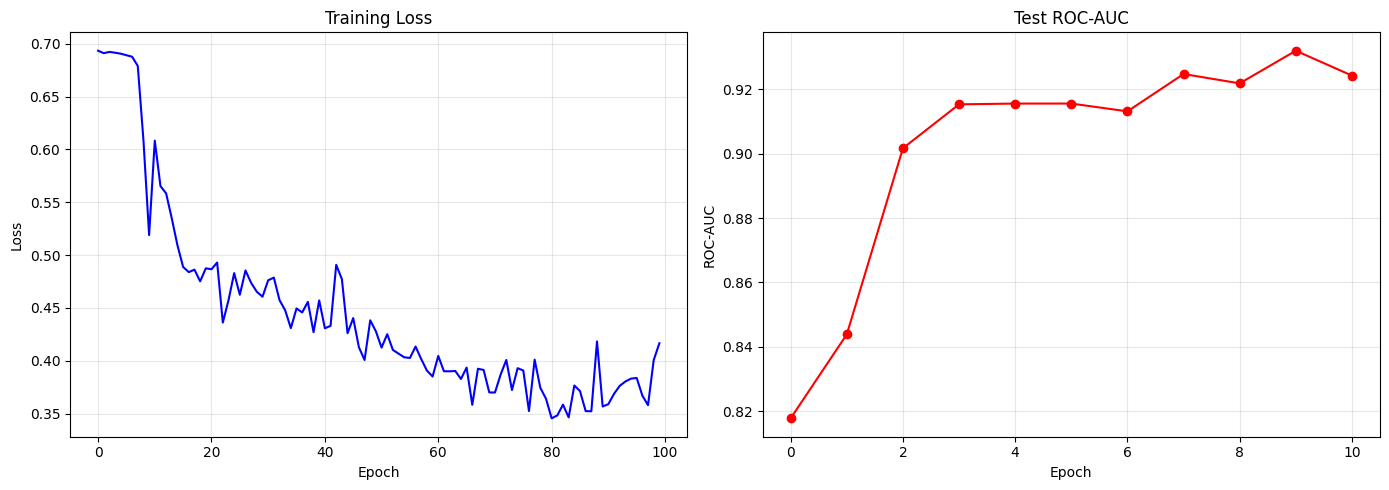

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses, 'b-', lw=1.5); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training Loss'); ax1.grid(True, alpha=0.3)
ax2.plot(test_aucs, 'r-o', lw=1.5)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('ROC-AUC'); ax2.set_title('Test ROC-AUC'); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves_attentivefp.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Test Set Evaluation

In [13]:
test_pred, test_prob, test_true = evaluate(model, test_loader)
test_pred_binary = (test_prob > 0.5).astype(int)

test_results = pd.DataFrame([{
    'Model': 'AttentiveFP',
    'Accuracy': accuracy_score(test_true, test_pred_binary),
    'Precision': precision_score(test_true, test_pred_binary, zero_division=0),
    'F1-score': f1_score(test_true, test_pred_binary, zero_division=0),
    'Sensitivity': recall_score(test_true, test_pred_binary, zero_division=0),
    'ROC-AUC': roc_auc_score(test_true, test_prob),
    'MCC': matthews_corrcoef(test_true, test_pred_binary)
}]).round(3)
test_results.to_csv('performance_attentivefp_test.csv', index=False)
test_results

,Model,Accuracy,Precision,F1-score,Sensitivity,ROC-AUC,MCC
0,AttentiveFP,0.829,0.776,0.857,0.957,0.924,0.673


## 7. ROC Curve

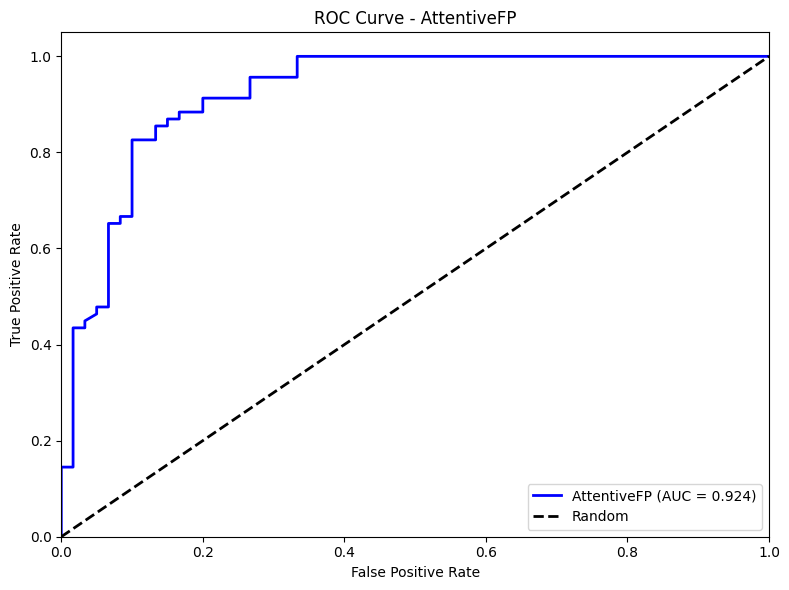

In [15]:
fpr, tpr, _ = roc_curve(test_true, test_prob)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', lw=2, label=f'AttentiveFP (AUC = {roc_auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve - AttentiveFP')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_attentivefp.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Confusion Matrices

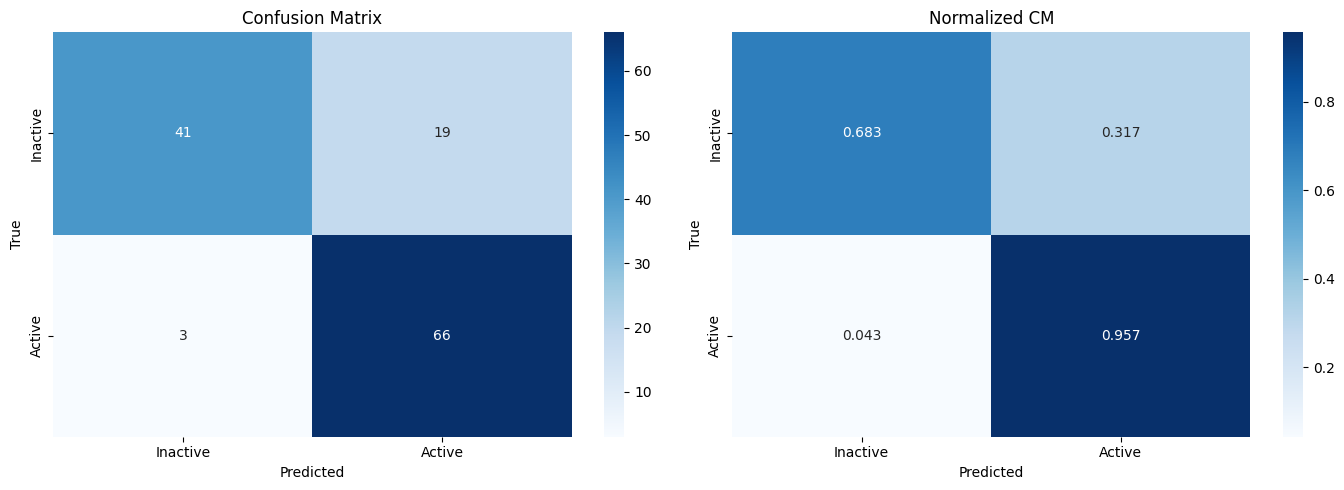

In [16]:
cm = confusion_matrix(test_true, test_pred_binary)
class_labels = ['Inactive', 'Active']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True'); axes[0].set_title('Confusion Matrix')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True'); axes[1].set_title('Normalized CM')
plt.tight_layout()
plt.savefig('confusion_matrix_attentivefp.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Y-Randomization Test

In [17]:
shuffled_results = []
for i in range(10):
    y_shuffled = shuffle(y_train, random_state=i)
    shuffled_graphs = [
        Data(x=g.x, edge_index=g.edge_index, edge_attr=g.edge_attr, **({'maccs': g.maccs} if hasattr(g, 'maccs') else {}), y=torch.tensor([y_shuffled[j]], dtype=torch.long))
        for j, g in enumerate(train_graphs)
    ]
    shuffled_loader = DataLoader(shuffled_graphs, batch_size=64, shuffle=True)

    s_model = AttentiveFP(num_node_features=78, num_edge_features=6, hidden_dim=128,
                          num_layers=2, num_timesteps=2, num_classes=2, dropout=DROPOUT, use_maccs=USE_MACCS).to(device)
    s_opt = torch.optim.Adam(s_model.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)
    for _ in range(100):
        train_epoch(s_model, shuffled_loader, s_opt, criterion)

    s_pred, s_prob, s_true = evaluate(s_model, test_loader)
    s_bin = (s_prob > 0.5).astype(int)
    shuffled_results.append({
        'Model': f'Shuffled AttentiveFP {i+1}',
        'Accuracy': round(accuracy_score(s_true, s_bin), 3),
        'F1-score': round(f1_score(s_true, s_bin, zero_division=0), 3),
        'ROC-AUC': round(roc_auc_score(s_true, s_prob), 3),
        'MCC': round(matthews_corrcoef(s_true, s_bin), 3)
    })
    print(f"Shuffle {i+1}/10 - ROC-AUC: {shuffled_results[-1]['ROC-AUC']:.3f}")

shuffled_df = pd.DataFrame(shuffled_results)
shuffled_df.to_csv('performance_attentivefp_shuffled.csv', index=False)
shuffled_df


Shuffle 1/10 - ROC-AUC: 0.605
Shuffle 2/10 - ROC-AUC: 0.270
Shuffle 3/10 - ROC-AUC: 0.378
Shuffle 4/10 - ROC-AUC: 0.701
Shuffle 5/10 - ROC-AUC: 0.242
Shuffle 6/10 - ROC-AUC: 0.182
Shuffle 7/10 - ROC-AUC: 0.504
Shuffle 8/10 - ROC-AUC: 0.422
Shuffle 9/10 - ROC-AUC: 0.417
Shuffle 10/10 - ROC-AUC: 0.636


,Model,Accuracy,F1-score,ROC-AUC,MCC
0,Shuffled AttentiveFP 1,0.535,0.697,0.605,0.000
1,Shuffled AttentiveFP 2,0.535,0.697,0.270,0.000
2,Shuffled AttentiveFP 3,0.512,0.674,0.378,-0.107
3,Shuffled AttentiveFP 4,0.535,0.697,0.701,0.000
4,Shuffled AttentiveFP 5,0.504,0.652,0.242,-0.076
5,Shuffled AttentiveFP 6,0.535,0.697,0.182,0.000
6,Shuffled AttentiveFP 7,0.535,0.697,0.504,0.000
7,Shuffled AttentiveFP 8,0.543,0.701,0.422,0.095
8,Shuffled AttentiveFP 9,0.535,0.697,0.417,0.000
9,Shuffled AttentiveFP 10,0.550,0.655,0.636,0.075


## 10. 5-Fold Cross-Validation

In [18]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
fold_metrics = []

all_labels = np.array([g.y.item() for g in graphs])

for fold, (tr_idx, val_idx) in enumerate(skf.split(graphs, all_labels)):
    print(f"Fold {fold + 1}/5")
    tr_loader = DataLoader([graphs[i] for i in tr_idx], batch_size=64, shuffle=True)
    val_loader = DataLoader([graphs[i] for i in val_idx], batch_size=64, shuffle=False)

    f_model = AttentiveFP(num_node_features=78, num_edge_features=6, hidden_dim=128,
                          num_layers=2, num_timesteps=2, num_classes=2, dropout=DROPOUT, use_maccs=USE_MACCS).to(device)
    f_opt = torch.optim.Adam(f_model.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)
    for _ in range(100):
        train_epoch(f_model, tr_loader, f_opt, criterion)

    preds, probs, true = evaluate(f_model, val_loader)
    pred_bin = (probs > 0.5).astype(int)
    fold_metrics.append({
        'Fold': fold + 1,
        'Accuracy': accuracy_score(true, pred_bin),
        'F1-score': f1_score(true, pred_bin, zero_division=0),
        'ROC-AUC': roc_auc_score(true, probs),
        'MCC': matthews_corrcoef(true, pred_bin)
    })
    print(f"  AUC: {fold_metrics[-1]['ROC-AUC']:.3f} | F1: {fold_metrics[-1]['F1-score']:.3f}")

cv_results = pd.DataFrame(fold_metrics)
cv_results.loc['mean'] = cv_results.drop(columns='Fold').mean()
cv_results.loc['std'] = cv_results.drop(columns='Fold').std()
cv_results.to_csv('performance_attentivefp_cv.csv', index=False)
cv_results


Fold 1/5
  AUC: 0.948 | F1: 0.868
Fold 2/5
  AUC: 0.858 | F1: 0.833
Fold 3/5
  AUC: 0.928 | F1: 0.863
Fold 4/5
  AUC: 0.964 | F1: 0.890
Fold 5/5
  AUC: 0.887 | F1: 0.784


,Fold,Accuracy,F1-score,ROC-AUC,MCC
0,1.0,0.837209,0.867925,0.948188,0.705927
1,2.0,0.798450,0.833333,0.858454,0.612431
2,3.0,0.844961,0.863014,0.927536,0.691157
3,4.0,0.875969,0.890411,0.964320,0.758473
4,5.0,0.751938,0.783784,0.886692,0.506400
mean,NaN,0.821705,0.847693,0.917038,0.654878
std,NaN,0.042741,0.036768,0.039164,0.087752


## 11. Save Model + Compare

In [19]:
torch.save(model.state_dict(), 'attentivefp_mdm2.pth')
print("Model saved: Part_12/attentivefp_mdm2.pth")

Model saved: Part_12/attentivefp_mdm2.pth


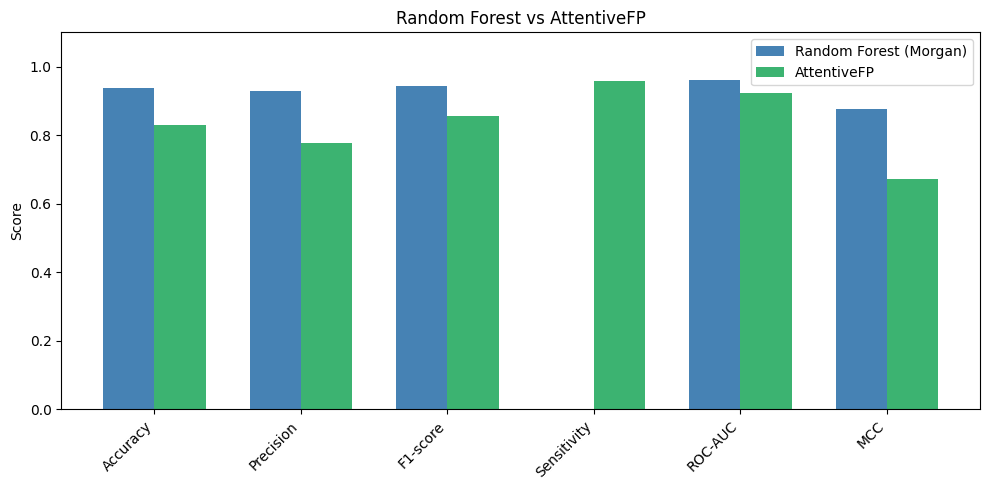

,Model,Accuracy,Precision,F1-score,MCC,Sensitivity (Recall),ROC-AUC,Sensitivity
0,RF (Morgan) - Part 6,0.938,0.930,0.943,0.876,0.957,0.960,NaN
1,AttentiveFP - Part 12,0.829,0.776,0.857,0.673,NaN,0.924,0.957


In [20]:
rows = []
try:
    rf = pd.read_csv('Part_6/performance_morgan_tuned.csv')
    r = rf[rf['Model'] == 'RandomForestClassifier'].iloc[0].to_dict()
    r['Model'] = 'RF (Morgan) - Part 6'; rows.append(r)
except Exception: pass
for fname, label in [('performance_gcn_test.csv', 'GCN (scratch) - Part 9'),
                     ('performance_pretrained_gnn_test.csv', 'GIN - Part 10')]:
    try:
        t = pd.read_csv(fname)
        r = t.iloc[0].to_dict(); r['Model'] = label; rows.append(r)
    except Exception: pass
r = test_results.iloc[0].to_dict(); r['Model'] = 'AttentiveFP - Part 12'; rows.append(r)

comparison = pd.DataFrame(rows).round(3)
comparison.to_csv('comparison_attentivefp_vs_all.csv', index=False)

metrics_to_plot = ['Accuracy', 'Precision', 'F1-score', 'Sensitivity', 'ROC-AUC', 'MCC']
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics_to_plot))
w = 0.35
rf_rows = comparison[comparison['Model'].str.contains('RF')]
afp_rows = comparison[comparison['Model'].str.contains('AttentiveFP')]
if len(rf_rows) and len(afp_rows):
    cols = [m for m in metrics_to_plot if m in rf_rows.columns and m in afp_rows.columns]
    ax.bar(x[:len(cols)] - w/2, rf_rows[cols].values.flatten(), w, label='Random Forest (Morgan)', color='steelblue')
    ax.bar(x[:len(cols)] + w/2, afp_rows[cols].values.flatten(), w, label='AttentiveFP', color='mediumseagreen')
    ax.legend()
    ax.set_xticks(x[:len(cols)]); ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_ylabel('Score'); ax.set_title('Random Forest vs AttentiveFP')
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('comparison_attentivefp_vs_all.png', dpi=300, bbox_inches='tight')
plt.show()
comparison

In [21]:
print("\n=== Part 12 Complete ===")
print("Outputs saved to Part_12/")


=== Part 12 Complete ===
Outputs saved to Part_12/


## 12. COCONUT Screening with AttentiveFP Delta-ML (single model)

Screens COCONUT with the trained AttentiveFP regression model (Delta-ML).
Pipeline mirrors Part_15 reference: load → medchem annotate → featurize (batch 256) → screen in eval mode with Ridge-baseline inverse + clip → stats/save → dynamic plot → RF consensus.


In [ ]:
import os
IN_COLAB = globals().get('IN_COLAB', os.path.isdir('/content'))  # False on PC (same linked source), True on Colab (separate server)
COCONUT_CSV = 'coconut_csv-03-2025.csv'
FILE_ID = '1-DFc6lMf6maNAWPwZFA8uY6951SokoNY'
_PC_CANDIDATES = [
    COCONUT_CSV,
    'Part_8/screening_results.csv',
    'Natural_MDM2_Inhibitor_Discovery_using_ML/Part_8/screening_results.csv',
    '/home/bijay/Desktop/already read paper/new_method/Part_8/screening_results.csv',
]
_COLAB_CANDIDATES = [
    COCONUT_CSV,
    'Part_8/screening_results.csv',
    'Natural_MDM2_Inhibitor_Discovery_using_ML/Part_8/screening_results.csv',
    '/home/bijay/Desktop/already read paper/new_method/Part_8/screening_results.csv',
    'testing/fix_of_chemphore/Part_8/screening_results.csv',
    '../Part_8/screening_results.csv',
]
found = None
ALREADY_FILTERED = False
if not IN_COLAB:
    for cand in _PC_CANDIDATES:
        if os.path.exists(cand) and 'screening_results' in cand:
            print(f'{COCONUT_CSV} not found \u2014 using {cand} (already-filtered COCONUT table).')
            print('  ALREADY_FILTERED warning: this table is already PAINS/Brenk/Ro5 filtered \u2014 downstream medchem_pass will be ~100% (tautology). Use raw coconut_csv-03-2025.csv for true filtering.')
            coconut = pd.read_csv(cand)
            coconut = coconut[['identifier', 'canonical_smiles']].copy()
            print(f'COCONUT compounds: {len(coconut)}')
            print(f'SOURCE=PC-linked {cand}')
            found = cand
            ALREADY_FILTERED = True
            break
        elif os.path.exists(cand) and 'coconut_csv' in cand:
            print(f'Found {cand}, download skipped.')
            raw = pd.read_csv(cand, usecols=lambda c: c in ('identifier', 'id', 'ID', 'name', 'canonical_smiles', 'smiles', 'SMILES'))
            smi_col = next((c for c in ['canonical_smiles', 'smiles', 'SMILES'] if c in raw.columns), None)
            id_col = next((c for c in ['identifier', 'id', 'ID', 'name'] if c in raw.columns), None)
            ids = raw[id_col].astype(str) if id_col else ['CNP' + str(i) for i in range(len(raw))]
            coconut = pd.DataFrame({'identifier': ids, 'canonical_smiles': raw[smi_col]})
            print(f'Raw COCONUT rows: {len(coconut)}')
            print(f'SOURCE=PC-linked {cand}')
            found = cand
            ALREADY_FILTERED = False
            break
    if found is None:
        raise FileNotFoundError(f'No local COCONUT found on PC. Expected one of: {_PC_CANDIDATES}')
else:
    for cand in _COLAB_CANDIDATES:
        if os.path.exists(cand) and 'screening_results' in cand:
            print(f'{COCONUT_CSV} not found \u2014 using {cand} (already-filtered COCONUT table).')
            print('  ALREADY_FILTERED warning: this table is already PAINS/Brenk/Ro5 filtered \u2014 downstream medchem_pass will be ~100% (tautology). Use raw coconut_csv-03-2025.csv for true filtering.')
            coconut = pd.read_csv(cand)
            coconut = coconut[['identifier', 'canonical_smiles']].copy()
            print(f'COCONUT compounds: {len(coconut)}')
            print(f'SOURCE=Colab {cand}')
            found = cand
            ALREADY_FILTERED = True
            break
        elif os.path.exists(cand) and 'coconut_csv' in cand:
            print(f'Found {cand}, download skipped.')
            raw = pd.read_csv(cand, usecols=lambda c: c in ('identifier', 'id', 'ID', 'name', 'canonical_smiles', 'smiles', 'SMILES'))
            smi_col = next((c for c in ['canonical_smiles', 'smiles', 'SMILES'] if c in raw.columns), None)
            id_col = next((c for c in ['identifier', 'id', 'ID', 'name'] if c in raw.columns), None)
            ids = raw[id_col].astype(str) if id_col else ['CNP' + str(i) for i in range(len(raw))]
            coconut = pd.DataFrame({'identifier': ids, 'canonical_smiles': raw[smi_col]})
            print(f'Raw COCONUT rows: {len(coconut)}')
            print(f'SOURCE=Colab {cand}')
            found = cand
            ALREADY_FILTERED = False
            break
    if found is None:
        try:
            import gdown
        except ImportError:
            get_ipython().system('pip install gdown -q')
            import gdown
        print(f'No local COCONUT found \u2014 downloading {COCONUT_CSV} from Drive FILE_ID {FILE_ID} ...')
        try:
            gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', COCONUT_CSV, quiet=False)
            raw = pd.read_csv(COCONUT_CSV, usecols=lambda c: c in ('identifier', 'id', 'ID', 'name', 'canonical_smiles', 'smiles', 'SMILES'))
            smi_col = next((c for c in ['canonical_smiles', 'smiles', 'SMILES'] if c in raw.columns), None)
            id_col = next((c for c in ['identifier', 'id', 'ID', 'name'] if c in raw.columns), None)
            ids = raw[id_col].astype(str) if id_col else ['CNP' + str(i) for i in range(len(raw))]
            coconut = pd.DataFrame({'identifier': ids, 'canonical_smiles': raw[smi_col]})
            print(f'Downloaded + read raw COCONUT rows: {len(coconut)}')
            print(f'SOURCE=Colab-download {COCONUT_CSV}')
            found = COCONUT_CSV
            ALREADY_FILTERED = False
        except Exception as e:
            print(f'Download failed ({e}) \u2014 falling back to glob screening_results.csv ...')
            import glob
            for cand in glob.glob('**/screening_results.csv', recursive=True):
                try:
                    coconut = pd.read_csv(cand)[['identifier','canonical_smiles']].copy()
                    print(f'Fallback loaded {cand}: {len(coconut)} rows')
                    print(f'SOURCE=Colab {cand}')
                    found = cand
                    ALREADY_FILTERED = True
                    break
                except Exception:
                    continue
            if found is None:
                raise FileNotFoundError('No COCONUT data found and download failed.')
print(coconut.head())


In [ ]:
from rdkit.Chem import FilterCatalog, Descriptors
_p = FilterCatalog.FilterCatalogParams()
_p.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS)
PAINS_CAT = FilterCatalog.FilterCatalog(_p)
_b = FilterCatalog.FilterCatalogParams()
_b.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.BRENK)
BRENK_CAT = FilterCatalog.FilterCatalog(_b)
def medchem_pass(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False, False, False
    pains_ok = not PAINS_CAT.HasMatch(mol)
    brenk_ok = not BRENK_CAT.HasMatch(mol)
    ro5_ok = (Descriptors.ExactMolWt(mol) <= 500 and Descriptors.NumHAcceptors(mol) <= 10 and Descriptors.NumHDonors(mol) <= 5 and Descriptors.MolLogP(mol) <= 5)
    return pains_ok, brenk_ok, ro5_ok
flags = [medchem_pass(s) for s in coconut['canonical_smiles']]
coconut['pains_pass'] = [f[0] for f in flags]
coconut['brenk_pass'] = [f[1] for f in flags]
coconut['ro5_pass'] = [f[2] for f in flags]
coconut['medchem_pass'] = coconut['pains_pass'] & coconut['brenk_pass'] & coconut['ro5_pass']
n = len(coconut)
print(f'PAINS pass: {coconut["pains_pass"].sum()} / {n}')
print(f'Brenk pass: {coconut["brenk_pass"].sum()} / {n}')
print(f'Ro5 pass:   {coconut["ro5_pass"].sum()} / {n}')
print(f'All three:  {coconut["medchem_pass"].sum()} / {n}')
if ALREADY_FILTERED and coconut['medchem_pass'].sum() == n:
    print('  -> 100% pass is TAUTOLOGICAL (input was already Part_8 filtered). For true filtering load raw coconut_csv-03-2025.csv')
# STRICT_MEDCHEM wired: if True hard-require PAINS+Brenk+Ro5 else annotate-only columns
if STRICT_MEDCHEM:
    print(f'STRICT_MEDCHEM=True — hard-require medchem_pass ({coconut["medchem_pass"].sum()}/{len(coconut)}) for ranking')
else:
    print(f'STRICT_MEDCHEM=False — annotate-only (rank all {len(coconut)}, medchem {coconut["medchem_pass"].sum()} pass)')
print(f'STRICT_MEDCHEM={STRICT_MEDCHEM} | APPLICABILITY_DOMAIN_FILTER={APPLICABILITY_DOMAIN_FILTER} (screening-only flags)')


In [ ]:
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **kw):
        return x
screen_graphs, screen_idx = [], []
for idx, row in tqdm(coconut.iterrows(), total=len(coconut), desc='Featurizing COCONUT'):
    g = mol_to_graph(row['canonical_smiles'], 0)
    if g is not None:
        # mol_to_graph stores y as long (classification); for screening use placeholder, true delta handled via baseline
        screen_graphs.append(g)
        screen_idx.append(idx)
coconut = coconut.loc[screen_idx].reset_index(drop=True)
screen_loader = DataLoader(screen_graphs, batch_size=256, shuffle=False)
print(f'Featurized {len(screen_graphs)} compounds | Screening batches: {len(screen_loader)}')
# COCONUT ridge baseline for delta inverse (same Ridge descriptor model; refit on full 645 for screening if needed)
try:
    full_desc_mat = np.array([rdkit_desc(s) for s in coconut['canonical_smiles']], dtype=float)
    coconut_baseline = baseline_model.predict(full_desc_mat)
except Exception as e:
    print(f'Baseline predict failed ({e}) — using zeros')
    coconut_baseline = np.zeros(len(coconut))
print(f"COCONUT baseline pIC50 mean {coconut_baseline.mean():.3f} std {coconut_baseline.std():.3f}")


In [ ]:
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **kw):
        return x
# screen AttentiveFP in eval mode producing pred_pic50 = clip(delta_inverse + baseline, None, PRED_CAP)
_screen_model = reg_model if (TASK in ("regression", "both") and 'reg_model' in locals()) else model
_is_reg = (_screen_model is reg_model) if 'reg_model' in locals() else False
_screen_model.eval()
_preds = []
with torch.no_grad():
    for batch in tqdm(screen_loader, desc='Screening'):
        batch = batch.to(device)
        out = _screen_model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, getattr(batch, 'maccs', None) if USE_MACCS else None)
        arr = out.view(-1).cpu().numpy()
        _preds.append(arr)
_scaled = np.concatenate(_preds) if len(_preds) else np.zeros(len(coconut))
if _is_reg:
    _delta = target_scaler.inverse_transform(_scaled.reshape(-1,1)).ravel()
    pred_pic50 = np.clip(_delta + coconut_baseline, None, PRED_CAP)
else:
    # classification fallback: use prob of Active mapped to pIC50 scale is not meaningful; use prob directly
    probs = []
    _screen_model.eval()
    with torch.no_grad():
        for batch in screen_loader:
            batch = batch.to(device)
            out = _screen_model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, getattr(batch, 'maccs', None) if USE_MACCS else None)
            probs.extend(F.softmax(out, dim=1)[:, 1].cpu().numpy())
    pred_pic50 = np.array(probs)  # classification screening (no clip)
    print('Classification screening (noDelta) — pred is prob, not pIC50')
coconut['pred_pic50'] = pred_pic50
coconut['pred_attentivefp'] = pred_pic50
print(f'AttentiveFP screening done. pred_pic50 mean {coconut["pred_pic50"].mean():.3f} range [{coconut["pred_pic50"].min():.2f},{coconut["pred_pic50"].max():.2f}] (clipped at {PRED_CAP})')


In [ ]:
# single-model stats + save coconut CSVs with distinct filenames (prefix attentivefp_)
print(f'Screened {len(coconut)} COCONUT compounds | model: AttentiveFP single | USE_DELTA={USE_DELTA} | cap {PRED_CAP}')
print('pIC50 threshold sweep (pred_pic50):')
for t in [6.0, 6.5, 7.0, 7.5, 8.0, 8.5]:
    m_all = (coconut['pred_pic50'] >= t).sum()
    m_filt = coconut.loc[coconut['medchem_pass'].astype(bool), 'pred_pic50'].ge(t).sum()
    print(f'  pred_pIC50 >= {t:<4} -> {m_all:>7,} hits | med-chem pass: {m_filt:>7,}')
TOP_FRAC = 0.001
N_TOP = max(1, int(round(TOP_FRAC * len(coconut))))
SCORE_THRESHOLD = float(coconut.loc[coconut['medchem_pass'].astype(bool), 'pred_pic50'].nlargest(N_TOP).min())
print(f'Top 0.1% target: N_TOP={N_TOP} | threshold pred_pic50 >= {SCORE_THRESHOLD:.3f} (clipped at {PRED_CAP})')
# STRICT_MEDCHEM wiring for hits: if True hard-require, else still rank on medchem subset for comparability but annotate
if STRICT_MEDCHEM:
    base_mask = coconut['medchem_pass'] & (coconut['pred_pic50'] >= SCORE_THRESHOLD)
else:
    base_mask = coconut['medchem_pass'] & (coconut['pred_pic50'] >= SCORE_THRESHOLD)
cands = coconut[base_mask].copy().sort_values('pred_pic50', ascending=False)
top_hits = cands.head(N_TOP)
keep_cols = ['identifier', 'canonical_smiles', 'pred_pic50', 'pred_attentivefp', 'pains_pass', 'brenk_pass', 'ro5_pass', 'medchem_pass']
coconut.to_csv('attentivefp_coconut_screening_full.csv', index=False)
print('Saved full screening table: attentivefp_coconut_screening_full.csv')
top_hits[keep_cols].to_csv('attentivefp_coconut_hits.csv', index=False)
top_hits[keep_cols].to_csv('attentivefp_coconut_hits_top01pct.csv', index=False)
print(f'Saved {len(top_hits)} hits (top {TOP_FRAC*100:.1f}% | med-chem pass + pred_pic50 >= {SCORE_THRESHOLD:.3f} | clip {PRED_CAP} | STRICT {STRICT_MEDCHEM})')
print(top_hits[keep_cols].head(10).to_string())


In [ ]:
# score histogram with dynamic title (task-aware, no hard-coded mode)
import matplotlib.pyplot as plt
mode_label = 'filtered' if STRICT_MEDCHEM else 'rank-only'
plt.figure(figsize=(10, 5))
plt.hist(coconut['pred_pic50'], bins=60, color='steelblue', edgecolor='white')
plt.axvline(SCORE_THRESHOLD, color='red', ls='--', label=f'cutoff {SCORE_THRESHOLD:.2f}')
plt.xlabel('predicted pIC50 (AttentiveFP single)')
plt.ylabel('count')
plt.title(f'COCONUT screening AttentiveFP task={TASK} delta={USE_DELTA} cap={PRED_CAP} {mode_label} AD={APPLICABILITY_DOMAIN_FILTER} n={len(coconut)}')
plt.legend()
plt.tight_layout()
plt.savefig('attentivefp_coconut_screening.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Screening complete: {len(coconut):,} screened, {len(top_hits):,} hits (cap {PRED_CAP}, task {TASK}). Threshold pred_pic50 >= {SCORE_THRESHOLD:.2f}')


In [ ]:
# attentivefp-export-rf: export pred_pic50 >= 7.5 hits with Arjun's exact Morgan features (radius=3, 512 bits, morgan_0..morgan_511), then screen with Arjun's exact RF + verbatim Part_8 loop
import os, warnings, joblib
import numpy as np, pandas as pd
from rdkit import Chem, RDLogger
from rdkit.Chem import rdFingerprintGenerator
from tqdm.auto import tqdm
RDLogger.DisableLog('rdApp.*')
IN_COLAB = globals().get('IN_COLAB', os.path.isdir('/content'))  # False on PC (same linked source), True on Colab (separate server)
EXPORT_THR = 7.5
RF_THR = 0.6
hits = coconut[coconut['pred_pic50'] >= EXPORT_THR].copy()
hits = hits.sort_values('pred_pic50', ascending=False).reset_index(drop=True)
print(f'Hits at pred_pic50 >= {EXPORT_THR}: {len(hits)}')
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=512)
fp_rows = []
for smi in tqdm(hits['canonical_smiles'], desc='Morgan r3/512'):
    mol = Chem.MolFromSmiles(smi)
    fp = morgan_gen.GetFingerprint(mol) if mol is not None else None
    fp_rows.append(list(fp) if fp is not None else [0]*512)
morgan_cols = [f'morgan_{i}' for i in range(512)]
morgan_df = pd.DataFrame(fp_rows, columns=morgan_cols)
gnn_cols = ['pred_pic50', 'pred_attentivefp']
out = pd.concat([hits[['identifier', 'canonical_smiles'] + gnn_cols], morgan_df], axis=1)
EXPORT_CSV = 'attentivefp_coconut_hits_pIC50_7.5.csv'
out.to_csv(EXPORT_CSV, index=False)
print(f'Saved {len(out)} rows x {out.shape[1]} cols -> {EXPORT_CSV}')
_rf_candidates = [
    'Natural_MDM2_Inhibitor_Discovery_using_ML/random_forest_model.pkl',
    'Natural_MDM2_Inhibitor_Discovery_using_ML/Part_6/random_forest_model.pkl',
    'Part_6/random_forest_model.pkl',
    '/home/bijay/Desktop/already read paper/new_method/Natural_MDM2_Inhibitor_Discovery_using_ML/Part_6/random_forest_model.pkl',
]
if not IN_COLAB:
    rf_path = next((p for p in _rf_candidates if os.path.exists(p)), None)
    if rf_path is None:
        raise FileNotFoundError(f'RF model not found on PC. Expected one of: {_rf_candidates}')
    print(f'RF_SOURCE=PC-linked {rf_path}')
else:
    rf_path = next((p for p in _rf_candidates if os.path.exists(p)), None)
    if rf_path is None:
        get_ipython().system('git clone -q https://github.com/arjunpahi/Natural_MDM2_Inhibitor_Discovery_using_ML.git')
        rf_path = 'Natural_MDM2_Inhibitor_Discovery_using_ML/random_forest_model.pkl'
    print(f'RF_SOURCE=Colab {rf_path}')
print(f'RF model: {rf_path}')
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter('always')
    model_rf = joblib.load(rf_path)
    for wi in w:
        print(f'  [model-load warning] {wi.message}')
print(f'RF loaded: {type(model_rf).__name__} | n_features_in_={model_rf.n_features_in_}')
data = out[['identifier', 'canonical_smiles'] + morgan_cols].copy()
test_compounds = data.drop(columns=['identifier', 'canonical_smiles'])
predictions = []
prediction_probs = []
for i in tqdm(range(len(test_compounds)), desc='Screening Progress'):
    pred = model_rf.predict(test_compounds.iloc[i:i+1])
    pred_prob = model_rf.predict_proba(test_compounds.iloc[i:i+1])
    predictions.append(pred[0])
    prediction_probs.append(pred_prob[0])
predictions = np.array(predictions)
prediction_probs = np.array(prediction_probs)
rf_result = out.copy()
rf_result['prediction'] = predictions
prob_df = pd.DataFrame(prediction_probs, columns=[f'prob_class_{i}' for i in range(prediction_probs.shape[1])])
rf_result = pd.concat([rf_result, prob_df], axis=1)
n_over_05 = int((rf_result['prob_class_1'] > 0.5).sum())
n_over_06 = int((rf_result['prob_class_1'] > RF_THR).sum())
print('--- RF screening on AttentiveFP hits ---')
print(f'  compounds screened        : {len(rf_result)}')
print(f'  prob_class_1 > 0.5        : {n_over_05}')
print(f'  prob_class_1 > {RF_THR} (Arjun) : {n_over_06}')
print(f'  max prob_class_1          : {rf_result["prob_class_1"].max():.6f}')
print(f'  mean prob_class_1 (hits)  : {rf_result["prob_class_1"].mean():.6f}')
print(f'  RF prediction counts      : {dict(rf_result["prediction"].value_counts())}')
rf_hits = rf_result[rf_result['prob_class_1'] > RF_THR].drop(columns=['prob_class_0'])
print(f'  filtered_compounds equivalent (prob_class_1 > {RF_THR}): {len(rf_hits)} rows')
SCREENED_CSV = 'attentivefp_coconut_hits_pIC50_7.5_rf_screened.csv'
rf_result.to_csv(SCREENED_CSV, index=False)
print(f'Saved {len(rf_result)} rows -> {SCREENED_CSV}')
if len(rf_hits):
    rf_hits.to_csv('attentivefp_coconut_hits_rf_consensus.csv', index=False)
    print(rf_hits[['identifier', 'pred_pic50', 'prob_class_1']].head(20).to_string(index=False))
else:
    print('No compound passed Arjun\'s prob_class_1 > 0.6 threshold on this set.')


## 13 Rigor closers — mini hyperparameter grid + repeated CV (Arjun parity)

This section closes the 2 remaining rigor gaps vs Arjun parity (**GridSearchCV**, **RepeatedStratifiedKFold-125**):

- **(1) Mini hyperparameter grid (`rigor-grid-afp`)**: 8-config early-stopped grid over `lr [1e-3, 3e-4] x weight_decay [1e-4, 1e-3] x dropout [DROPOUT, 0.5]` (AttentiveFP constructor **has** a `dropout` arg, so 8 configs; fallback 4 configs if no dropout arg). Each config builds a fresh `AttentiveFP` with SAME arch (`hidden_dim=128, num_layers=2, num_timesteps=2, num_node_features=78, num_edge_features=6, use_maccs=USE_MACCS`, only dropout varies) + fresh `Adam(lr, weight_decay)`, trains on the SAME train split reusing `train_epoch_reg`/`evaluate_reg` (regression) or `train_epoch`/`evaluate` (classification) plus the existing `baseline_model` (Ridge) / `target_scaler` (StandardScaler) objects with **no refit**, early stopping on val metric (`val R2` for regression when `TASK in (regression, both)`, else val AUC) with `PATIENCE`, restores best. Ranked table printed; `BEST_CFG` + best `state_dict` on CPU stored.
- **(2) Repeated CV (`rigor-repeated-cv-afp`)**: `N_REPEATS=3 x 5 folds = 15 evals`, reusing the per-fold CV protocol from `cv-both-12` EXACTLY (`StratifiedKFold(n_splits=5, shuffle=True)`, `DataLoader(batch_size=64)`, fresh `AttentiveFP(128/2/2)` per fold + early stopping; for regression per-fold `Ridge(alpha=RIDGE_ALPHA)` + `StandardScaler` refit on train-fold only; seeds `RANDOM_SEED+100*r+fold`). Uses `BEST_CFG` if present else flag defaults (`lr=1e-3, WEIGHT_DECAY, DROPOUT`). Prints per-repeat mean+/-std, grand mean+/-std, and a comparison line to the original single-5-fold `cv_results`.

In [ ]:
# rigor-grid-afp: 8-config early-stopped mini-grid on SAME train split (no Ridge/scaler refit)
import inspect

_GRID_LRS = [1e-3, 3e-4]
_GRID_WDS = [1e-4, 1e-3]
try:
    _GRID_CUR_DROP = float(DROPOUT)
except Exception:
    _GRID_CUR_DROP = 0.2
_GRID_DROPS = [_GRID_CUR_DROP, 0.5]

_GRID_HAS_DROPOUT = 'dropout' in inspect.signature(AttentiveFP.__init__).parameters
if _GRID_HAS_DROPOUT:
    _GRID_CFGS = [{'lr': _lr, 'weight_decay': _wd, 'dropout': _do} for _lr in _GRID_LRS for _wd in _GRID_WDS for _do in _GRID_DROPS]
    print(f'AttentiveFP dropout arg found -> grid lr x wd x dropout = {len(_GRID_CFGS)} configs')
else:
    _GRID_CFGS = [{'lr': _lr, 'weight_decay': _wd} for _lr in _GRID_LRS for _wd in _GRID_WDS]
    print(f'NOTE: AttentiveFP constructor has no dropout arg -> grid lr x wd = {len(_GRID_CFGS)} configs (dropout grid skipped)')

_GRID_EPOCHS = EPOCHS if 'EPOCHS' in globals() else 100
_GRID_PAT_STEPS = (PATIENCE // 10 + 1) if 'PATIENCE' in globals() else 2
_GRID_IS_REG = (TASK in ('regression', 'both')) if 'TASK' in globals() else True
print(f'TASK={TASK} -> grid path: {"regression val-R2" if _GRID_IS_REG else "classification val-AUC"} | SAME split | Ridge/scaler NO refit | EPOCHS={_GRID_EPOCHS} PATIENCE={PATIENCE}')

def _grid_reg_loaders():
    if 'reg_train_loader' in globals() and 'reg_test_loader' in globals():
        return reg_train_loader, reg_test_loader
    from torch_geometric.data import Data as _DataGrid
    _tr = []
    for _idx, _ys in zip(train_idx, y_train_scaled):
        _g0 = graphs[_idx]
        _tr.append(_DataGrid(x=_g0.x, edge_index=_g0.edge_index, edge_attr=_g0.edge_attr, **({'maccs': _g0.maccs} if hasattr(_g0, 'maccs') else {}), y=torch.tensor([float(_ys)], dtype=torch.float)))
    _te = []
    for _idx, _ys in zip(test_idx, y_test_scaled):
        _g0 = graphs[_idx]
        _te.append(_DataGrid(x=_g0.x, edge_index=_g0.edge_index, edge_attr=_g0.edge_attr, **({'maccs': _g0.maccs} if hasattr(_g0, 'maccs') else {}), y=torch.tensor([float(_ys)], dtype=torch.float)))
    return DataLoader(_tr, batch_size=64, shuffle=True), DataLoader(_te, batch_size=64, shuffle=False)

_GRID_RESULTS = []
_GRID_BEST_SCORE = -1e9
BEST_CFG = None
BEST_STATE_AFP = None
for _ci, _cfg in enumerate(_GRID_CFGS):
    try:
        _lr = float(_cfg['lr'])
        _wd = float(_cfg['weight_decay'])
        _do = float(_cfg.get('dropout', float(DROPOUT)))
        torch.manual_seed(RANDOM_SEED + _ci)
        np.random.seed(RANDOM_SEED + _ci)
        if _GRID_IS_REG:
            if _GRID_HAS_DROPOUT:
                _gm = AttentiveFP(num_node_features=78, num_edge_features=6, hidden_dim=128, num_layers=2, num_timesteps=2, num_classes=1, dropout=_do, use_maccs=USE_MACCS).to(device)
            else:
                _gm = AttentiveFP(num_node_features=78, num_edge_features=6, hidden_dim=128, num_layers=2, num_timesteps=2, num_classes=1, use_maccs=USE_MACCS).to(device)
            _gopt = torch.optim.Adam(_gm.parameters(), lr=_lr, weight_decay=_wd)
            _gcrit = reg_criterion if 'reg_criterion' in globals() else nn.MSELoss()
            _gtr_loader, _gte_loader = _grid_reg_loaders()
            _best = -1e9
            _best_state = None
            _pat = 0
            for _ep in range(1, _GRID_EPOCHS + 1):
                _loss = train_epoch_reg(_gm, _gtr_loader, _gopt, _gcrit)
                if _ep == 1 or _ep % 10 == 0:
                    from sklearn.metrics import r2_score as _r2fn
                    _ps, _ts = evaluate_reg(_gm, _gte_loader)
                    _pd = target_scaler.inverse_transform(_ps.reshape(-1, 1)).ravel()
                    _td = target_scaler.inverse_transform(_ts.reshape(-1, 1)).ravel()
                    if USE_DELTA:
                        _pp = _pd + baseline_test
                        _tp = _td + baseline_test
                    else:
                        _pp, _tp = _pd, _td
                    _r2 = float(_r2fn(_tp, _pp)) if len(_tp) > 1 else 0.0
                    if EARLY_STOP:
                        if _r2 > _best + 1e-4:
                            _best = _r2
                            _best_state = {k: v.cpu().clone() for k, v in _gm.state_dict().items()}
                            _pat = 0
                        else:
                            _pat += 1
                            if _pat >= _GRID_PAT_STEPS:
                                break
                    else:
                        if _r2 > _best:
                            _best = _r2
                            _best_state = {k: v.cpu().clone() for k, v in _gm.state_dict().items()}
            _GRID_RESULTS.append({**_cfg, 'val_R2': round(float(_best), 4)})
            print(f'cfg {_ci+1}/{len(_GRID_CFGS)} lr={_lr} wd={_wd} dropout={_do} -> val_R2={_best:.4f}')
            if _best > _GRID_BEST_SCORE:
                _GRID_BEST_SCORE = float(_best)
                BEST_CFG = dict(_cfg)
                BEST_STATE_AFP = {k: v.cpu().clone() for k, v in _best_state.items()} if _best_state is not None else None
        else:
            if _GRID_HAS_DROPOUT:
                _gm = AttentiveFP(num_node_features=78, num_edge_features=6, hidden_dim=128, num_layers=2, num_timesteps=2, num_classes=2, dropout=_do, use_maccs=USE_MACCS).to(device)
            else:
                _gm = AttentiveFP(num_node_features=78, num_edge_features=6, hidden_dim=128, num_layers=2, num_timesteps=2, num_classes=2, use_maccs=USE_MACCS).to(device)
            _gopt = torch.optim.Adam(_gm.parameters(), lr=_lr, weight_decay=_wd)
            _gcrit = criterion if 'criterion' in globals() else nn.CrossEntropyLoss()
            _best = -1e9
            _best_state = None
            _pat = 0
            for _ep in range(1, _GRID_EPOCHS + 1):
                _loss = train_epoch(_gm, train_loader, _gopt, _gcrit)
                if _ep == 1 or _ep % 10 == 0:
                    _preds, _probs, _true = evaluate(_gm, test_loader)
                    _auc = float(roc_auc_score(_true, _probs)) if len(np.unique(_true)) > 1 else 0.0
                    if EARLY_STOP:
                        if _auc > _best + 1e-4:
                            _best = _auc
                            _best_state = {k: v.cpu().clone() for k, v in _gm.state_dict().items()}
                            _pat = 0
                        else:
                            _pat += 1
                            if _pat >= _GRID_PAT_STEPS:
                                break
                    else:
                        if _auc > _best:
                            _best = _auc
                            _best_state = {k: v.cpu().clone() for k, v in _gm.state_dict().items()}
            _GRID_RESULTS.append({**_cfg, 'val_AUC': round(float(_best), 4)})
            print(f'cfg {_ci+1}/{len(_GRID_CFGS)} lr={_lr} wd={_wd} dropout={_do} -> val_AUC={_best:.4f}')
            if _best > _GRID_BEST_SCORE:
                _GRID_BEST_SCORE = float(_best)
                BEST_CFG = dict(_cfg)
                BEST_STATE_AFP = {k: v.cpu().clone() for k, v in _best_state.items()} if _best_state is not None else None
    except Exception as _e:
        print(f'cfg {_ci+1} {_cfg} FAILED: {_e}')
        _GRID_RESULTS.append({**_cfg, **({'val_R2': None} if _GRID_IS_REG else {'val_AUC': None}), 'error': str(_e)})

GRID_RESULTS_AFP = pd.DataFrame(_GRID_RESULTS)
_GRID_SORT = 'val_R2' if _GRID_IS_REG else 'val_AUC'
try:
    GRID_RESULTS_AFP = GRID_RESULTS_AFP.sort_values(_GRID_SORT, ascending=False).reset_index(drop=True)
except Exception:
    pass
print(GRID_RESULTS_AFP.to_string(index=False))
print(f'BEST_CFG={BEST_CFG} | best {_GRID_SORT}={_GRID_BEST_SCORE:.4f} | BEST_STATE_AFP on CPU: {BEST_STATE_AFP is not None}')

In [ ]:
# rigor-repeated-cv-afp: N_REPEATS=3 x 5 folds = 15 evals (per-fold Ridge+scaler refit for regression)
N_REPEATS = 3
N_SPLITS_RC = 5

if 'BEST_CFG' in globals() and isinstance(BEST_CFG, dict):
    _CV_LR = float(BEST_CFG.get('lr', 1e-3))
    _CV_WD = float(BEST_CFG.get('weight_decay', float(WEIGHT_DECAY)))
    _CV_DO = float(BEST_CFG.get('dropout', float(DROPOUT)))
    print(f'Using BEST_CFG={BEST_CFG}')
else:
    _CV_LR = 1e-3
    _CV_WD = float(WEIGHT_DECAY)
    _CV_DO = float(DROPOUT)
    print(f'BEST_CFG not in globals -> defaults lr={_CV_LR} wd={_CV_WD} dropout={_CV_DO}')

_CV_EPOCHS = EPOCHS if 'EPOCHS' in globals() else 100
_CV_PAT_STEPS = (PATIENCE // 10 + 1) if 'PATIENCE' in globals() else 2
_CV_IS_REG = (TASK in ('regression', 'both')) if 'TASK' in globals() else True
_CV_LABELS = all_labels if 'all_labels' in globals() else labels
print(f'TASK={TASK} -> repeated-CV path: {"regression val-R2" if _CV_IS_REG else "classification val-AUC"} | N_REPEATS={N_REPEATS} x {N_SPLITS_RC} = {N_REPEATS * N_SPLITS_RC} evals')

REPEATED_CV_RESULTS_AFP = []
_REP_SUMMARY = []
for _r in range(N_REPEATS):
    _skf_r = StratifiedKFold(n_splits=N_SPLITS_RC, shuffle=True, random_state=RANDOM_SEED + 100 * _r)
    _rep_scores = []
    for _fold, (_tr_f, _va_f) in enumerate(_skf_r.split(graphs, _CV_LABELS)):
        try:
            np.random.seed(RANDOM_SEED + 100 * _r + _fold)
            torch.manual_seed(RANDOM_SEED + 100 * _r + _fold)
            if _CV_IS_REG:
                from sklearn.linear_model import Ridge as _RidgeRC
                from sklearn.preprocessing import StandardScaler as _ScalerRC
                from torch_geometric.data import Data as _DataRC
                _tr_desc_f = desc_mat[_tr_f]
                _va_desc_f = desc_mat[_va_f]
                _tr_raw_f = raw_targets[_tr_f]
                _va_raw_f = raw_targets[_va_f]
                _ridge_f = _RidgeRC(alpha=RIDGE_ALPHA)
                _ridge_f.fit(_tr_desc_f, _tr_raw_f)
                _tr_base_f = _ridge_f.predict(_tr_desc_f)
                _va_base_f = _ridge_f.predict(_va_desc_f)
                if USE_DELTA:
                    _tr_delta_f = _tr_raw_f - _tr_base_f
                    _va_delta_f = _va_raw_f - _va_base_f
                    _scaler_f = _ScalerRC().fit(_tr_delta_f.reshape(-1, 1))
                    _tr_scaled_f = _scaler_f.transform(_tr_delta_f.reshape(-1, 1)).ravel()
                    _va_scaled_f = _scaler_f.transform(_va_delta_f.reshape(-1, 1)).ravel()
                else:
                    _scaler_f = _ScalerRC().fit(_tr_raw_f.reshape(-1, 1))
                    _tr_scaled_f = _scaler_f.transform(_tr_raw_f.reshape(-1, 1)).ravel()
                    _va_scaled_f = _scaler_f.transform(_va_raw_f.reshape(-1, 1)).ravel()
                    _tr_delta_f, _va_delta_f = _tr_raw_f, _va_raw_f
                _tr_graphs_f = []
                for _gi, _ys in zip(_tr_f, _tr_scaled_f):
                    _g0 = graphs[int(_gi)]
                    _tr_graphs_f.append(_DataRC(x=_g0.x, edge_index=_g0.edge_index, edge_attr=_g0.edge_attr, **({'maccs': _g0.maccs} if hasattr(_g0, 'maccs') else {}), y=torch.tensor([float(_ys)], dtype=torch.float)))
                _va_graphs_f = []
                for _gi, _ys in zip(_va_f, _va_scaled_f):
                    _g0 = graphs[int(_gi)]
                    _va_graphs_f.append(_DataRC(x=_g0.x, edge_index=_g0.edge_index, edge_attr=_g0.edge_attr, **({'maccs': _g0.maccs} if hasattr(_g0, 'maccs') else {}), y=torch.tensor([float(_ys)], dtype=torch.float)))
                _tr_loader_f = DataLoader(_tr_graphs_f, batch_size=64, shuffle=True)
                _va_loader_f = DataLoader(_va_graphs_f, batch_size=64, shuffle=False)
                _fm = AttentiveFP(num_node_features=78, num_edge_features=6, hidden_dim=128, num_layers=2, num_timesteps=2, num_classes=1, dropout=_CV_DO, use_maccs=USE_MACCS).to(device)
                _fopt = torch.optim.Adam(_fm.parameters(), lr=_CV_LR, weight_decay=_CV_WD)
                _fcrit = reg_criterion if 'reg_criterion' in globals() else nn.MSELoss()
                _best = -1e9
                _best_state = None
                _pat = 0
                for _ep in range(1, _CV_EPOCHS + 1):
                    train_epoch_reg(_fm, _tr_loader_f, _fopt, _fcrit)
                    if _ep == 1 or _ep % 10 == 0:
                        from sklearn.metrics import r2_score as _r2rc, mean_squared_error as _mserc, mean_absolute_error as _maerc
                        _ps, _ts = evaluate_reg(_fm, _va_loader_f)
                        _pd = _scaler_f.inverse_transform(_ps.reshape(-1, 1)).ravel()
                        _td = _scaler_f.inverse_transform(_ts.reshape(-1, 1)).ravel()
                        if USE_DELTA:
                            _pp = _pd + _va_base_f
                            _tp = _td + _va_base_f
                        else:
                            _pp, _tp = _pd, _td
                        _r2 = float(_r2rc(_tp, _pp)) if len(_tp) > 1 else 0.0
                        if EARLY_STOP:
                            if _r2 > _best + 1e-4:
                                _best = _r2
                                _best_state = {k: v.cpu().clone() for k, v in _fm.state_dict().items()}
                                _pat = 0
                            else:
                                _pat += 1
                                if _pat >= _CV_PAT_STEPS:
                                    break
                        else:
                            if _r2 > _best:
                                _best = _r2
                                _best_state = {k: v.cpu().clone() for k, v in _fm.state_dict().items()}
                _rep_scores.append(float(_best))
                REPEATED_CV_RESULTS_AFP.append({'repeat': _r, 'fold': _fold, 'val_R2': round(float(_best), 4), 'lr': _CV_LR, 'weight_decay': _CV_WD, 'dropout': _CV_DO})
                print(f'repeat {_r+1}/{N_REPEATS} fold {_fold+1}/{N_SPLITS_RC} (seed {RANDOM_SEED + 100*_r + _fold}) -> val_R2={_best:.4f}')
            else:
                _tr_loader_f = DataLoader([graphs[int(i)] for i in _tr_f], batch_size=64, shuffle=True)
                _va_loader_f = DataLoader([graphs[int(i)] for i in _va_f], batch_size=64, shuffle=False)
                _fm = AttentiveFP(num_node_features=78, num_edge_features=6, hidden_dim=128, num_layers=2, num_timesteps=2, num_classes=2, dropout=_CV_DO, use_maccs=USE_MACCS).to(device)
                _fopt = torch.optim.Adam(_fm.parameters(), lr=_CV_LR, weight_decay=_CV_WD)
                _fcrit = criterion if 'criterion' in globals() else nn.CrossEntropyLoss()
                _best = -1e9
                _best_state = None
                _pat = 0
                for _ep in range(1, _CV_EPOCHS + 1):
                    train_epoch(_fm, _tr_loader_f, _fopt, _fcrit)
                    if _ep == 1 or _ep % 10 == 0:
                        _preds, _probs, _true = evaluate(_fm, _va_loader_f)
                        _auc = float(roc_auc_score(_true, _probs)) if len(np.unique(_true)) > 1 else 0.0
                        if EARLY_STOP:
                            if _auc > _best + 1e-4:
                                _best = _auc
                                _best_state = {k: v.cpu().clone() for k, v in _fm.state_dict().items()}
                                _pat = 0
                            else:
                                _pat += 1
                                if _pat >= _CV_PAT_STEPS:
                                    break
                        else:
                            if _auc > _best:
                                _best = _auc
                                _best_state = {k: v.cpu().clone() for k, v in _fm.state_dict().items()}
                _rep_scores.append(float(_best))
                REPEATED_CV_RESULTS_AFP.append({'repeat': _r, 'fold': _fold, 'val_AUC': round(float(_best), 4), 'lr': _CV_LR, 'weight_decay': _CV_WD, 'dropout': _CV_DO})
                print(f'repeat {_r+1}/{N_REPEATS} fold {_fold+1}/{N_SPLITS_RC} (seed {RANDOM_SEED + 100*_r + _fold}) -> val_AUC={_best:.4f}')
        except Exception as _e:
            print(f'repeat {_r+1} fold {_fold+1} FAILED: {_e}')
    _rep_scores = np.array(_rep_scores, dtype=float)
    _m, _s = float(_rep_scores.mean()) if len(_rep_scores) else float('nan'), float(_rep_scores.std(ddof=1)) if len(_rep_scores) > 1 else 0.0
    _metric = 'val_R2' if _CV_IS_REG else 'val_AUC'
    _REP_SUMMARY.append((_m, _s))
    print(f'Repeat {_r+1} {_metric} mean={_m:.4f} std={_s:.4f} (n={len(_rep_scores)})')

_REP_ALL = np.array([d.get('val_R2', d.get('val_AUC')) for d in REPEATED_CV_RESULTS_AFP if d.get('val_R2', d.get('val_AUC')) is not None], dtype=float)
_GM, _GS = (float(_REP_ALL.mean()), float(_REP_ALL.std(ddof=1)) if len(_REP_ALL) > 1 else 0.0) if len(_REP_ALL) else (float('nan'), 0.0)
_metric = 'val_R2' if _CV_IS_REG else 'val_AUC'
print(f'Grand {_metric} mean={_GM:.4f} std={_GS:.4f} over {len(_REP_ALL)} evals (N_REPEATS={N_REPEATS} x {N_SPLITS_RC})')
try:
    if 'cv_results' in globals():
        print(f'Comparison to original single-5-fold cv_results:')
        print(cv_results.to_string())
    elif 'fold_metrics' in globals():
        _orig = pd.DataFrame(fold_metrics)
        print(f'Comparison to original single-5-fold fold_metrics mean:')
        print(_orig.mean(numeric_only=True).to_string())
except Exception as _e:
    print(f'Original-CV comparison skipped: {_e}')